# Connections between Pseudo and FCM products

## Thresholds and computability rules used

- **Upstream input filter:** FCM product-store series require at least 30 active days and 10 positive-demand days; Pseudo series require at least 120 active days and 30 positive-demand days.
- **Analysis period:** observations from 14 April 2025 onward.
- **High-evidence discovery matrix:** each product-store profile requires at least 12 weeks and positive total demand; products require at least 10 qualifying stores and 26 profile weeks; each displayed correlation requires at least 26 overlapping weeks.
- **Controlling-team mapping audit:** no store-count or history-length policy threshold is used. Correlation is computable when both profiles exist, at least 2 weeks overlap, and both profiles vary over the overlap.
- **Change correlation:** requires at least 2 week-to-week changes and non-constant changes for both products.
- **Fisher 95% interval:** calculated only when more than 3 weeks overlap; this is a mathematical requirement of the interval formula, not an eligibility threshold.
- **ADI–CV² support:** any series with at least 1 positive-demand day is retained in this mapping-specific support view; ADI cutoff 1.32 and CV² cutoff 0.49.
- **Reporting only:** rank percentile `>= 75` defines the top-quartile summary but does not affect computability or inclusion.

This notebook asks whether recent FCM products move with Pseudo products and whether those empirical connections agree with the controlling-team mapping in `data/raw/fcm_pseudo/pseudo_zuordnung.json`.

FCM begins during 2025, so all correlations use absolute calendar weeks from 14 April 2025 onward. Two deliberately separate views are used:

- **High-evidence discovery matrix:** retains the conservative 12-week-per-store, 10-store, and 26-overlap-week rules when searching across every FCM–Pseudo combination.
- **Threshold-free mapping audit:** evaluates every mapped pair whenever correlation is mathematically computable. Both products must exist, have at least two overlapping profile weeks, and vary over those weeks. Store counts and overlap length are reported as evidence-quality diagnostics, never used as mapping eligibility filters.

Two measures are shown:

- **level correlation:** products are high and low in the same calendar weeks;
- **change correlation:** their week-to-week changes have the same direction, reducing the influence of shared launch ramps or slow trends.

These are descriptive connections, not evidence that one product causes or substitutes for another. ADI–CV² is added to show whether mapped products also have comparable demand frequency and positive-demand variability.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

DATA_DIR_CANDIDATES = [
    Path("../../data/interim/transactions_dst_daily_min_demand_no_outliers"),
    Path("data/interim/transactions_dst_daily_min_demand_no_outliers"),
]
MAPPING_CANDIDATES = [
    Path("../../data/raw/fcm_pseudo/pseudo_zuordnung.json"),
    Path("data/raw/fcm_pseudo/pseudo_zuordnung.json"),
]
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if p.exists()), None)
MAPPING_PATH = next((p for p in MAPPING_CANDIDATES if p.exists()), None)
if DATA_DIR is None or not any(DATA_DIR.glob("*.parquet")):
    raise FileNotFoundError(f"Daily parquet data not found; searched {DATA_DIR_CANDIDATES}")
if MAPPING_PATH is None:
    raise FileNotFoundError(f"FCM–Pseudo mapping not found; searched {MAPPING_CANDIDATES}")
DATA_GLOB = str(DATA_DIR / "*.parquet")

RECENT_START = "2025-04-14"
MIN_SERIES_WEEKS = 12
MIN_OVERLAP_WEEKS = 26
MIN_STORES = 10
ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49
SOURCE_COLORS = {"FCM": "#D45D45", "Pseudo": "#E3A83B"}
CLASS_ORDER = ["smooth", "erratic", "intermittent", "lumpy"]
CLASS_COLORS = {
    "smooth": "#2A9D8F", "erratic": "#E9C46A",
    "intermittent": "#457B9D", "lumpy": "#D62828",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})
con = duckdb.connect()
con.execute("PRAGMA threads=4")

mapping = pd.read_json(MAPPING_PATH).rename(columns={"FCM": "fcm_id", "PSEUDO": "pseudo_id"})
mapping["fcm_id"] = mapping.fcm_id.astype("int64")
mapping["pseudo_id"] = mapping.pseudo_id.astype("Int64")
mapping_audit = pd.DataFrame([{
    "mapping_rows": len(mapping),
    "distinct_FCM_products": mapping.fcm_id.nunique(),
    "rows_with_Pseudo_target": mapping.pseudo_id.notna().sum(),
    "FCM_products_without_target": mapping.loc[mapping.pseudo_id.isna(), "fcm_id"].nunique(),
    "distinct_Pseudo_targets": mapping.pseudo_id.nunique(),
}])
display(Markdown(f"**Mapping file:** `{MAPPING_PATH}`"))
display(mapping_audit)

**Mapping file:** `../../data/raw/fcm_pseudo/pseudo_zuordnung.json`

,mapping_rows,distinct_FCM_products,rows_with_Pseudo_target,FCM_products_without_target,distinct_Pseudo_targets
0,76,57,65,11,53


## 1. Build recent cross-store product profiles

The discovery profile first applies its conservative store-series evidence rule. A second mapping-specific profile then normalizes **every product-store series with positive recent mean demand**, without a minimum store or history count. This second profile is what makes the mapping audit threshold-free; evidence size remains visible in the output.

In [2]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE recent_weekly AS
SELECT ARTIKEL_ID AS article_id, any_value(ARTIKEL_BEZ) AS product_name,
       CASE WHEN bool_or(is_fcm) THEN 'FCM' ELSE 'Pseudo' END AS source_class,
       MARKT_ID AS store_id, date_trunc('week', DATE::DATE)::DATE AS week_date,
       sum(ABVERKAUFTE_MENGE_KG) AS demand_kg
FROM read_parquet('{DATA_GLOB}')
WHERE DATE::DATE >= DATE '{RECENT_START}' AND (is_fcm OR is_pseudo)
GROUP BY ARTIKEL_ID, MARKT_ID, date_trunc('week', DATE::DATE)
""")
con.execute(f"""
CREATE OR REPLACE TEMP TABLE recent_eligible AS
SELECT article_id, source_class, store_id, any_value(product_name) AS product_name,
       min(week_date) AS first_week, max(week_date) AS last_week
FROM recent_weekly
GROUP BY article_id, source_class, store_id
HAVING count(*) >= {MIN_SERIES_WEEKS} AND sum(demand_kg) > 0
""")
con.execute("""
CREATE OR REPLACE TEMP TABLE recent_normalized AS
WITH grid AS (
    SELECT e.article_id, e.product_name, e.source_class, e.store_id,
           generated.week_date::DATE AS week_date
    FROM recent_eligible e,
    LATERAL generate_series(e.first_week::TIMESTAMP, e.last_week::TIMESTAMP, INTERVAL 7 DAY) generated(week_date)
), filled AS (
    SELECT g.*, coalesce(w.demand_kg, 0.0) AS demand_kg
    FROM grid g LEFT JOIN recent_weekly w
      USING (article_id, source_class, store_id, week_date)
), means AS (
    SELECT *, avg(demand_kg) OVER (PARTITION BY article_id, source_class, store_id) AS mean_demand
    FROM filled
)
SELECT article_id, product_name, source_class, store_id, week_date,
       demand_kg / nullif(mean_demand, 0) AS normalized_demand
FROM means
""")
con.execute("""
CREATE OR REPLACE TEMP TABLE recent_product_profile AS
SELECT article_id, any_value(product_name) AS product_name, source_class, week_date,
       median(normalized_demand) AS profile_value,
       count(DISTINCT store_id) AS stores
FROM recent_normalized
GROUP BY article_id, source_class, week_date
""")

recent_info = con.execute("""
    SELECT article_id, any_value(product_name) AS product_name, source_class,
           max(stores) AS eligible_stores, count(*) AS profile_weeks,
           min(week_date) AS first_week, max(week_date) AS last_week
    FROM recent_product_profile
    GROUP BY article_id, source_class
""").fetchdf()
eligible_info = recent_info[
    (recent_info.eligible_stores >= MIN_STORES)
    & (recent_info.profile_weeks >= MIN_OVERLAP_WEEKS)
].copy()
display(
    eligible_info.groupby("source_class").agg(
        products=("article_id", "nunique"),
        median_stores=("eligible_stores", "median"),
        median_profile_weeks=("profile_weeks", "median"),
    )
)

# Threshold-free profiles used only for the controlling-team mapping audit.
con.execute("""
CREATE OR REPLACE TEMP TABLE mapping_normalized AS
WITH series_means AS (
    SELECT article_id, source_class, store_id,
           avg(demand_kg) AS mean_weekly_demand
    FROM recent_weekly
    GROUP BY article_id, source_class, store_id
    HAVING avg(demand_kg) > 0
)
SELECT w.article_id, w.product_name, w.source_class, w.store_id, w.week_date,
       w.demand_kg / m.mean_weekly_demand AS normalized_demand
FROM recent_weekly w
JOIN series_means m USING (article_id, source_class, store_id)
""")
con.execute("""
CREATE OR REPLACE TEMP TABLE mapping_product_profile AS
SELECT article_id, any_value(product_name) AS product_name, source_class, week_date,
       median(normalized_demand) AS profile_value,
       count(DISTINCT store_id) AS stores_in_week
FROM mapping_normalized
GROUP BY article_id, source_class, week_date
""")

mapping_info = con.execute("""
    SELECT p.article_id, any_value(p.product_name) AS product_name, p.source_class,
           count(DISTINCT p.week_date) AS profile_weeks,
           min(p.week_date) AS first_week, max(p.week_date) AS last_week,
           max(p.stores_in_week) AS maximum_stores_in_week,
           count(DISTINCT n.store_id) AS total_stores
    FROM mapping_product_profile p
    JOIN mapping_normalized n USING (article_id, source_class)
    GROUP BY p.article_id, p.source_class
""").fetchdf()
mapping_profiles = con.execute("""
    SELECT article_id, product_name, source_class, week_date, profile_value
    FROM mapping_product_profile
""").fetchdf()
mapping_profiles["key"] = (
    mapping_profiles.source_class + ":" + mapping_profiles.article_id.astype(str)
)
mapping_wide = mapping_profiles.pivot(
    index="week_date", columns="key", values="profile_value"
).sort_index()
mapping_name_lookup = mapping_info.assign(
    key=lambda x: x.source_class + ":" + x.article_id.astype(str)
).set_index("key").product_name.to_dict()
mapping_info_lookup = mapping_info.assign(
    key=lambda x: x.source_class + ":" + x.article_id.astype(str)
).set_index("key").to_dict("index")
mapping_pseudo_keys = sorted(
    key for key in mapping_wide.columns if key.startswith("Pseudo:")
)

display(Markdown("**Threshold-free mapping-profile coverage**"))
display(
    mapping_info.groupby("source_class").agg(
        products=("article_id", "nunique"),
        median_total_stores=("total_stores", "median"),
        median_profile_weeks=("profile_weeks", "median"),
    )
)


,products,median_stores,median_profile_weeks
source_class,,,
FCM,20,145.5,52.0
Pseudo,228,91.5,67.0


**Threshold-free mapping-profile coverage**

,products,median_total_stores,median_profile_weeks
source_class,,,
FCM,29,130.0,45.0
Pseudo,342,22.0,67.0


## 2. High-evidence FCM–Pseudo discovery matrix

,fcm_id,FCM product,pseudo_id,Pseudo product,level_correlation,change_correlation,listed_in_mapping
0,1401487,SB Nackensteaks Paprika v. Schwein,1185685,HofWerte Grillspezialitäten vom Schwein,0.764660,0.128449,False
1,1413120,Schweinebraten-Aufschnitt Gyros Art,747751,Geschnetzeltes vom Rind,0.700556,0.572048,False
2,1413151,Fleischkäse Cheddar-Jalapeno ofengebacken,1260007,Rinderfilet im Stück,0.693212,0.513421,False
3,1413151,Fleischkäse Cheddar-Jalapeno ofengebacken,1100454,Schlesische Weisswurst,0.674335,0.526292,False
4,1382863,Rostbratwurst (eigene Herstellung),1185679,HofWerte Grillspezialitäten vom Schwein,0.668954,0.631242,False
5,1401487,SB Nackensteaks Paprika v. Schwein,1185679,HofWerte Grillspezialitäten vom Schwein,0.664115,0.077282,False
6,1382863,Rostbratwurst (eigene Herstellung),1203487,Hofwerte Nackensteak Kräuter vom Schwein,0.653996,0.653063,False
7,1401487,SB Nackensteaks Paprika v. Schwein,911710,Frankreich Suppenfleisch vom Rind,0.650246,0.118465,False
8,1399512,Bockwurst,910328,Frankreich Beinscheibe vom Rind,0.648705,0.099615,False
9,1382863,Rostbratwurst (eigene Herstellung),317167,"Hüftsteak gewürzt, vom Rind",0.645607,0.659697,False


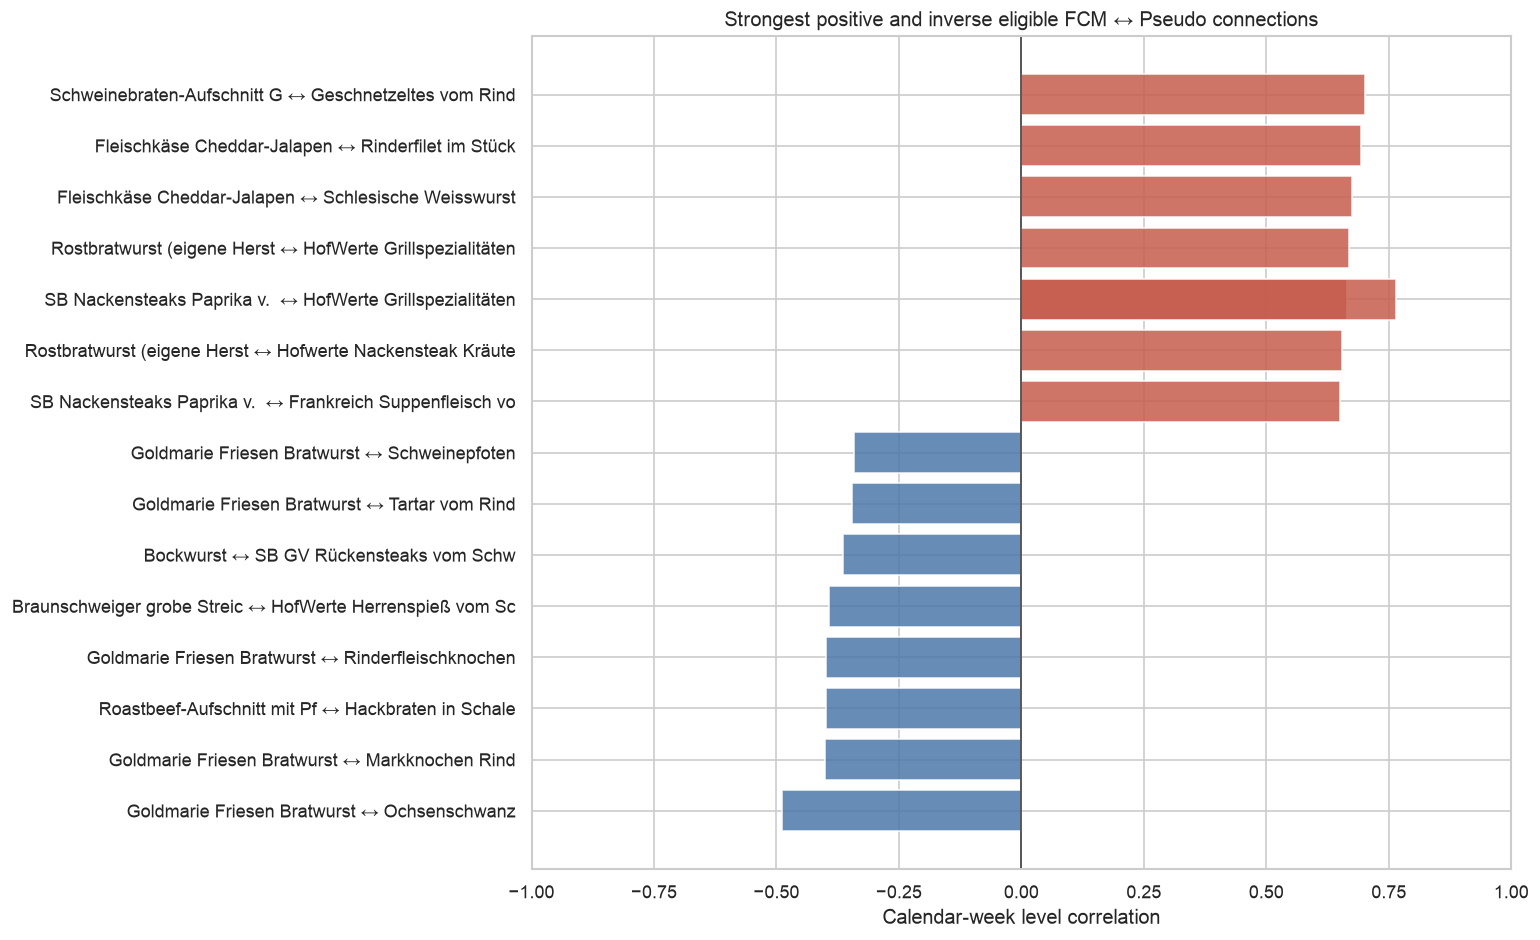

In [3]:
profiles = con.execute("""
    SELECT article_id, product_name, source_class, week_date, profile_value
    FROM recent_product_profile
""").fetchdf()
profiles["key"] = profiles.source_class + ":" + profiles.article_id.astype(str)
wide = profiles.pivot(index="week_date", columns="key", values="profile_value").sort_index()
level_corr = wide.corr(min_periods=MIN_OVERLAP_WEEKS)
change_corr = wide.diff().corr(min_periods=MIN_OVERLAP_WEEKS - 1)

eligible_keys = eligible_info.assign(
    key=lambda x: x.source_class + ":" + x.article_id.astype(str)
)
fcm_keys = eligible_keys.query("source_class == 'FCM'").key.tolist()
pseudo_keys = eligible_keys.query("source_class == 'Pseudo'").key.tolist()
fcm_keys = [k for k in fcm_keys if k in level_corr.index]
pseudo_keys = [k for k in pseudo_keys if k in level_corr.index]
corr_matrix = level_corr.loc[fcm_keys, pseudo_keys]
change_matrix = change_corr.loc[fcm_keys, pseudo_keys]
corr_matrix.index.name = "fcm_key"
corr_matrix.columns.name = "pseudo_key"
change_matrix.index.name = "fcm_key"
change_matrix.columns.name = "pseudo_key"

name_lookup = recent_info.assign(
    key=lambda x: x.source_class + ":" + x.article_id.astype(str)
).set_index("key").product_name.to_dict()
id_lookup = recent_info.assign(
    key=lambda x: x.source_class + ":" + x.article_id.astype(str)
).set_index("key").article_id.to_dict()

all_pairs = corr_matrix.stack().rename("level_correlation").reset_index()
all_pairs["change_correlation"] = [
    change_matrix.at[f, p] for f, p in zip(all_pairs.fcm_key, all_pairs.pseudo_key)
]
all_pairs["fcm_id"] = all_pairs.fcm_key.map(id_lookup).astype("int64")
all_pairs["pseudo_id"] = all_pairs.pseudo_key.map(id_lookup).astype("int64")
all_pairs["FCM product"] = all_pairs.fcm_key.map(name_lookup)
all_pairs["Pseudo product"] = all_pairs.pseudo_key.map(name_lookup)
mapped_key_set = set(
    mapping.dropna(subset=["pseudo_id"])[["fcm_id", "pseudo_id"]]
    .astype("int64").itertuples(index=False, name=None)
)
all_pairs["listed_in_mapping"] = [
    (fcm_id, pseudo_id) in mapped_key_set
    for fcm_id, pseudo_id in zip(all_pairs.fcm_id, all_pairs.pseudo_id)
]

strongest = all_pairs.nlargest(15, "level_correlation")
display(strongest[[
    "fcm_id", "FCM product", "pseudo_id", "Pseudo product",
    "level_correlation", "change_correlation", "listed_in_mapping",
]].reset_index(drop=True))

plot_pairs = pd.concat([
    all_pairs.nlargest(8, "level_correlation"),
    all_pairs.nsmallest(8, "level_correlation"),
]).drop_duplicates(["fcm_id", "pseudo_id"])
plot_pairs["pair"] = (
    plot_pairs["FCM product"].str.slice(0, 27) + " ↔ "
    + plot_pairs["Pseudo product"].str.slice(0, 27)
)
plot_pairs = plot_pairs.sort_values("level_correlation")
fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(
    plot_pairs.pair, plot_pairs.level_correlation,
    color=np.where(plot_pairs.level_correlation >= 0, "#C75D4D", "#4C78A8"),
    alpha=0.85,
)
ax.axvline(0, color="0.25", linewidth=1)
ax.set_xlim(-1, 1)
ax.set_xlabel("Calendar-week level correlation")
ax.set_title("Strongest positive and inverse eligible FCM ↔ Pseudo connections")
plt.tight_layout()
plt.show()

## 3. Threshold-free audit of the controlling-team mapping

Every non-null mapped pair is audited. There are no minimum store-count, history-length, or overlap-length policy thresholds in this section.

`correlation_computable` is true exactly when:

1. both mapped products have a recent cross-store profile;
2. at least two calendar weeks overlap; and
3. both profiles have non-zero variance on those overlapping weeks.

Two points are enough for Pearson correlation mathematically but always yield ±1, so `overlap_weeks`, store counts, and the Fisher 95% interval are shown rather than hidden behind eligibility cutoffs. Change correlation additionally needs at least two non-constant week-to-week changes. Rankings compare each mapped Pseudo product with every mathematically computable Pseudo candidate for the same FCM product.

In [4]:
def pair_statistics(fcm_key, pseudo_key):
    result = {
        "correlation_computable": False,
        "computability_reason": "",
        "overlap_weeks": 0,
        "level_correlation": np.nan,
        "level_ci_low_95": np.nan,
        "level_ci_high_95": np.nan,
        "change_correlation": np.nan,
    }
    if fcm_key not in mapping_wide.columns:
        result["computability_reason"] = "FCM product absent from recent profiles"
        return result
    if pseudo_key not in mapping_wide.columns:
        result["computability_reason"] = "Pseudo product absent from recent profiles"
        return result

    overlap = mapping_wide[[fcm_key, pseudo_key]].dropna()
    result["overlap_weeks"] = len(overlap)
    if len(overlap) < 2:
        result["computability_reason"] = "fewer than two overlapping weeks"
        return result
    if overlap[fcm_key].nunique() < 2 or overlap[pseudo_key].nunique() < 2:
        result["computability_reason"] = "constant profile on overlapping weeks"
        return result

    correlation = overlap[fcm_key].corr(overlap[pseudo_key])
    result["correlation_computable"] = pd.notna(correlation)
    result["computability_reason"] = "computable" if pd.notna(correlation) else "undefined correlation"
    result["level_correlation"] = correlation

    if len(overlap) > 3 and pd.notna(correlation):
        clipped = np.clip(correlation, -0.999999, 0.999999)
        fisher_z = np.arctanh(clipped)
        half_width = 1.96 / np.sqrt(len(overlap) - 3)
        result["level_ci_low_95"] = np.tanh(fisher_z - half_width)
        result["level_ci_high_95"] = np.tanh(fisher_z + half_width)

    changes = overlap.diff().dropna()
    if (
        len(changes) >= 2
        and changes[fcm_key].nunique() >= 2
        and changes[pseudo_key].nunique() >= 2
    ):
        result["change_correlation"] = changes[fcm_key].corr(changes[pseudo_key])
    return result


# Candidate universe for rank/percentile: mathematical computability only.
mapped_fcm_keys_present = sorted({
    f"FCM:{int(fcm_id)}"
    for fcm_id in mapping.fcm_id.unique()
    if f"FCM:{int(fcm_id)}" in mapping_wide.columns
})
candidate_rows = []
for fcm_key in mapped_fcm_keys_present:
    for pseudo_key in mapping_pseudo_keys:
        stats = pair_statistics(fcm_key, pseudo_key)
        if stats["correlation_computable"]:
            candidate_rows.append({
                "fcm_key": fcm_key,
                "pseudo_key": pseudo_key,
                "fcm_id": int(fcm_key.split(":", 1)[1]),
                "pseudo_id": int(pseudo_key.split(":", 1)[1]),
                "level_correlation": stats["level_correlation"],
            })
mapping_candidate_pairs = pd.DataFrame(candidate_rows)
if not mapping_candidate_pairs.empty:
    mapping_candidate_pairs["pseudo_rank_for_FCM"] = (
        mapping_candidate_pairs.groupby("fcm_key").level_correlation
        .rank(ascending=False, method="min")
    )
    candidate_counts = mapping_candidate_pairs.groupby("fcm_key").pseudo_key.transform("size")
    mapping_candidate_pairs["rank_percentile"] = (
        100
        * (candidate_counts - mapping_candidate_pairs.pseudo_rank_for_FCM + 1)
        / candidate_counts
    )
    mapping_candidate_pairs["pair_type"] = [
        "Mapped" if (f, p) in mapped_key_set else "Other computable candidate"
        for f, p in zip(
            mapping_candidate_pairs.fcm_id,
            mapping_candidate_pairs.pseudo_id,
        )
    ]

mapped_eval_rows = []
for row in mapping.dropna(subset=["pseudo_id"]).itertuples(index=False):
    fcm_id, pseudo_id = int(row.fcm_id), int(row.pseudo_id)
    fcm_key, pseudo_key = f"FCM:{fcm_id}", f"Pseudo:{pseudo_id}"
    stats = pair_statistics(fcm_key, pseudo_key)
    fcm_info = mapping_info_lookup.get(fcm_key, {})
    pseudo_info = mapping_info_lookup.get(pseudo_key, {})

    candidates = (
        mapping_candidate_pairs[mapping_candidate_pairs.fcm_key == fcm_key]
        .sort_values("level_correlation", ascending=False)
        if not mapping_candidate_pairs.empty else pd.DataFrame()
    )
    mapped_candidate = (
        candidates[candidates.pseudo_key == pseudo_key].iloc[0]
        if not candidates.empty and (candidates.pseudo_key == pseudo_key).any()
        else None
    )
    best_candidate = candidates.iloc[0] if not candidates.empty else None

    mapped_eval_rows.append({
        "fcm_id": fcm_id,
        "FCM product": mapping_name_lookup.get(fcm_key),
        "pseudo_id": pseudo_id,
        "Pseudo product": mapping_name_lookup.get(pseudo_key),
        "correlation_computable": stats["correlation_computable"],
        "computability_reason": stats["computability_reason"],
        "FCM stores": fcm_info.get("total_stores", 0),
        "Pseudo stores": pseudo_info.get("total_stores", 0),
        "overlap_weeks": stats["overlap_weeks"],
        "level_correlation": stats["level_correlation"],
        "level_ci_low_95": stats["level_ci_low_95"],
        "level_ci_high_95": stats["level_ci_high_95"],
        "change_correlation": stats["change_correlation"],
        "pseudo_rank_for_FCM": (
            mapped_candidate.pseudo_rank_for_FCM if mapped_candidate is not None else np.nan
        ),
        "rank_percentile": (
            mapped_candidate.rank_percentile if mapped_candidate is not None else np.nan
        ),
        "best_Pseudo_product": (
            mapping_name_lookup.get(best_candidate.pseudo_key)
            if best_candidate is not None else None
        ),
        "best_level_correlation": (
            best_candidate.level_correlation if best_candidate is not None else np.nan
        ),
        "mapped_is_best": bool(
            best_candidate is not None and best_candidate.pseudo_key == pseudo_key
        ),
    })

mapped_evaluation = pd.DataFrame(mapped_eval_rows)
display(
    mapped_evaluation.sort_values(
        ["correlation_computable", "level_correlation", "fcm_id"],
        ascending=[False, False, True], na_position="last",
    ).reset_index(drop=True)
)

reason_counts = (
    mapped_evaluation.computability_reason.value_counts(dropna=False)
    .rename_axis("result").rename("mapping_rows").reset_index()
)
display(Markdown("**Why mapped correlations are or are not computable**"))
display(reason_counts)

,fcm_id,FCM product,pseudo_id,Pseudo product,correlation_computable,computability_reason,FCM stores,Pseudo stores,overlap_weeks,level_correlation,level_ci_low_95,level_ci_high_95,change_correlation,pseudo_rank_for_FCM,rank_percentile,best_Pseudo_product,best_level_correlation,mapped_is_best
0,1402822,SB Schnitzel aus der Oberschale,1367847,GV Oberschalenschnitzel vom Schwein,True,computable,7,61,45,-0.078348,-0.363527,0.220256,-0.120833,175.0,47.590361,Cordonbleu vom Schwein,0.519135,False
1,1402822,SB Schnitzel aus der Oberschale,316783,Oberschalenschnitzel vom Schwein,True,computable,7,189,45,-0.193763,-0.461078,0.105793,-0.235508,288.0,13.554217,Cordonbleu vom Schwein,0.519135,False
2,1376569,None,318149,"Grillröllchen Schweinelachs mit Käsefüllung, m...",False,FCM product absent from recent profiles,0,188,0,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
3,1376691,None,818969,Hirtenröllchen m. Bacon,False,FCM product absent from recent profiles,0,186,0,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
4,1376698,None,317138,Grilltaschen vom Schwein gefüllt,False,FCM product absent from recent profiles,0,185,0,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,1422634,None,827673,"Souvlaki-Spieße aus dem Schweineschinken, mari...",False,FCM product absent from recent profiles,0,179,0,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
61,1422634,None,1206305,SB Souflaki-Spieß vom Schwein Gyros,False,FCM product absent from recent profiles,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
62,1422634,None,1206324,None,False,FCM product absent from recent profiles,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False
63,1422634,None,1206299,None,False,FCM product absent from recent profiles,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,False


**Why mapped correlations are or are not computable**

,result,mapping_rows
0,FCM product absent from recent profiles,57
1,Pseudo product absent from recent profiles,6
2,computable,2


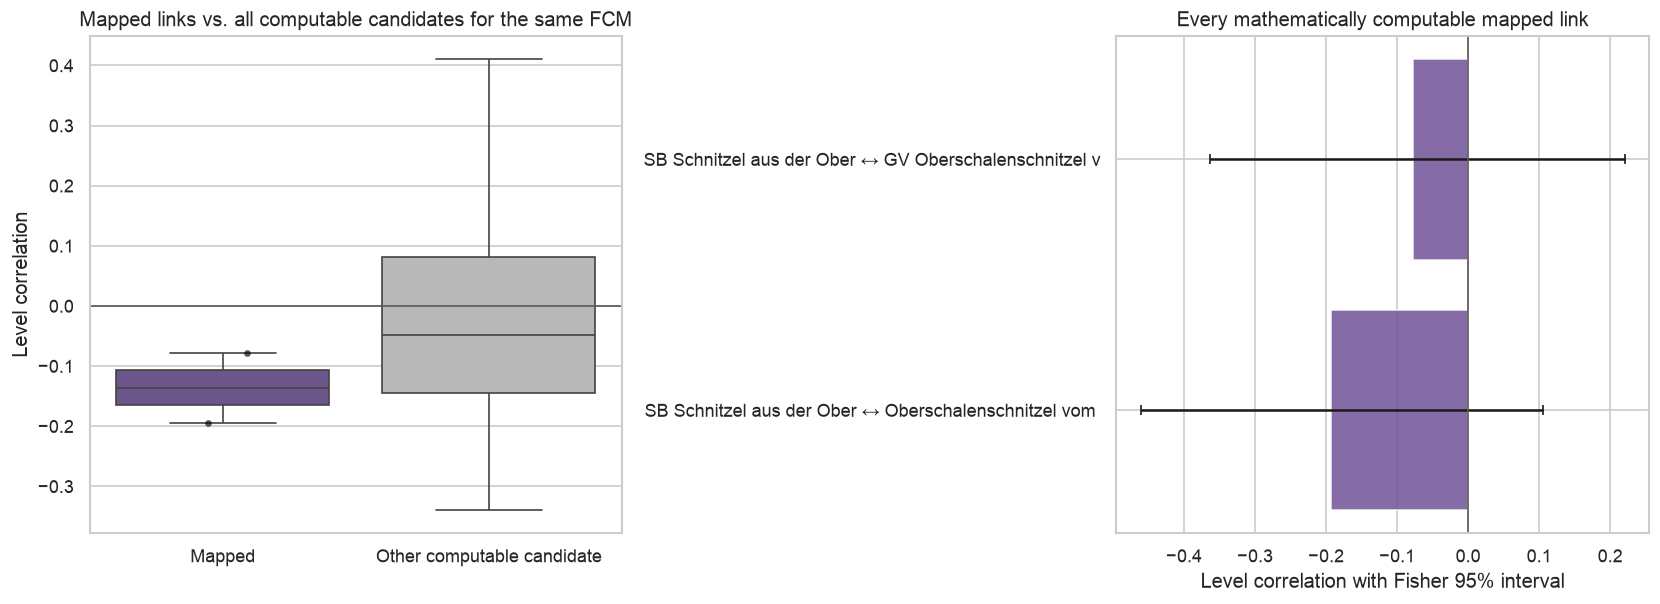

In [5]:
computable_mapped = mapped_evaluation.query("correlation_computable").copy()
computable_fcm_keys = {
    f"FCM:{int(fcm_id)}" for fcm_id in computable_mapped.fcm_id.unique()
}
plot_candidates = mapping_candidate_pairs[
    mapping_candidate_pairs.fcm_key.isin(computable_fcm_keys)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
if not plot_candidates.empty:
    sns.boxplot(
        data=plot_candidates, x="pair_type", y="level_correlation",
        order=["Mapped", "Other computable candidate"], hue="pair_type",
        palette={"Mapped": "#6A4C93", "Other computable candidate": "#B8B8B8"},
        showfliers=False, legend=False, ax=axes[0],
    )
    sns.stripplot(
        data=plot_candidates.query("pair_type == 'Mapped'"),
        x="pair_type", y="level_correlation",
        order=["Mapped", "Other computable candidate"],
        color="black", size=4, alpha=0.65, ax=axes[0],
    )
axes[0].axhline(0, color="0.35", linewidth=1)
axes[0].set(
    xlabel="", ylabel="Level correlation",
    title="Mapped links vs. all computable candidates for the same FCM",
)

if not computable_mapped.empty:
    plot_map = computable_mapped.copy()
    plot_map["pair"] = (
        plot_map["FCM product"].fillna(plot_map.fcm_id.astype(str)).str.slice(0, 25)
        + " ↔ "
        + plot_map["Pseudo product"].fillna(plot_map.pseudo_id.astype(str)).str.slice(0, 25)
    )
    plot_map = plot_map.sort_values("level_correlation")
    xerr = np.vstack([
        plot_map.level_correlation - plot_map.level_ci_low_95,
        plot_map.level_ci_high_95 - plot_map.level_correlation,
    ])
    axes[1].barh(
        plot_map.pair, plot_map.level_correlation,
        xerr=xerr, capsize=3, color="#6A4C93", alpha=0.82,
    )
    axes[1].axvline(0, color="0.35", linewidth=1)
    axes[1].set_xlabel("Level correlation with Fisher 95% interval")
    axes[1].set_title("Every mathematically computable mapped link")
fig.tight_layout()
plt.show()

## 4. ADI–CV² support for mapped connections

The mapping is strongest operationally when products resemble each other not only in calendar timing but also in demand regime. ADI and CV² are computed per daily product-store series and summarized by product. `demand_regime_match` compares the dominant store-series class; the continuous ADI/CV² columns retain information hidden by the four coarse classes.

,fcm_id,FCM product,pseudo_id,Pseudo product,level_correlation,change_correlation,fcm_dominant_demand_class,pseudo_dominant_demand_class,demand_regime_match,fcm_median_ADI,pseudo_median_ADI,fcm_median_CV2,pseudo_median_CV2,demand_regime_distance
0,1402822,SB Schnitzel aus der Oberschale,1367847,GV Oberschalenschnitzel vom Schwein,-0.078348,-0.120833,intermittent,intermittent,True,16.857143,8.620000,0.180045,0.335059,0.794112
1,1402822,SB Schnitzel aus der Oberschale,316783,Oberschalenschnitzel vom Schwein,-0.193763,-0.235508,intermittent,erratic,False,16.857143,1.201804,0.180045,1.236443,3.280285
2,1376569,None,318149,"Grillröllchen Schweinelachs mit Käsefüllung, m...",NaN,NaN,NaN,lumpy,False,NaN,1.887853,NaN,1.050821,NaN
3,1376691,None,818969,Hirtenröllchen m. Bacon,NaN,NaN,NaN,lumpy,False,NaN,5.194286,NaN,0.787901,NaN
4,1376698,None,317138,Grilltaschen vom Schwein gefüllt,NaN,NaN,NaN,lumpy,False,NaN,6.683824,NaN,0.810745,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,1422634,None,827673,"Souvlaki-Spieße aus dem Schweineschinken, mari...",NaN,NaN,NaN,lumpy,False,NaN,5.698113,NaN,0.946619,NaN
61,1422634,None,1206305,SB Souflaki-Spieß vom Schwein Gyros,NaN,NaN,NaN,intermittent,False,NaN,22.695781,NaN,0.310916,NaN
62,1422634,None,1206324,None,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
63,1422634,None,1206299,None,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN


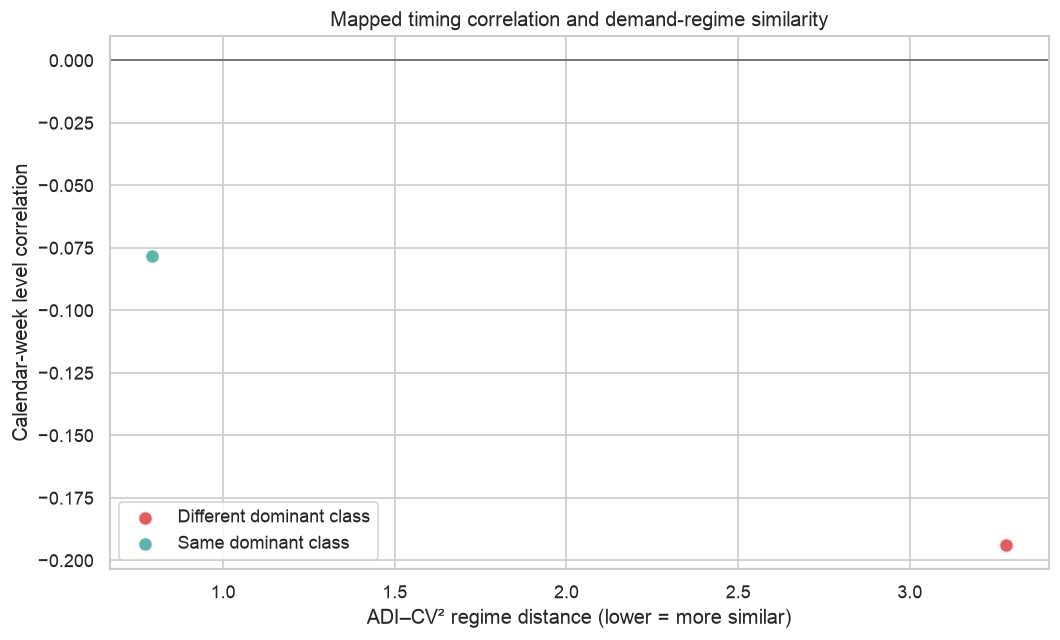

In [6]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE daily_adi_cv2 AS
WITH series AS (
    SELECT ARTIKEL_ID AS article_id, MARKT_ID AS store_id,
           CASE WHEN bool_or(is_fcm) THEN 'FCM' ELSE 'Pseudo' END AS source_class,
           count(*) AS active_days,
           count_if(ABVERKAUFTE_MENGE_KG > 0) AS demand_days,
           avg(CASE WHEN ABVERKAUFTE_MENGE_KG > 0 THEN ABVERKAUFTE_MENGE_KG END) AS mean_positive,
           var_samp(CASE WHEN ABVERKAUFTE_MENGE_KG > 0 THEN ABVERKAUFTE_MENGE_KG END) AS var_positive
    FROM read_parquet('{DATA_GLOB}')
    WHERE is_fcm OR is_pseudo GROUP BY ARTIKEL_ID, MARKT_ID
), metrics AS (
    SELECT *, active_days / nullif(demand_days, 0) AS ADI,
           CASE WHEN demand_days > 1 AND mean_positive > 0
                THEN var_positive / (mean_positive * mean_positive)
                WHEN demand_days = 1 THEN 0.0 END AS CV2
    FROM series WHERE demand_days > 0
)
SELECT *, CASE
    WHEN ADI < {ADI_CUTOFF} AND CV2 < {CV2_CUTOFF} THEN 'smooth'
    WHEN ADI < {ADI_CUTOFF} AND CV2 >= {CV2_CUTOFF} THEN 'erratic'
    WHEN ADI >= {ADI_CUTOFF} AND CV2 < {CV2_CUTOFF} THEN 'intermittent'
    WHEN ADI >= {ADI_CUTOFF} AND CV2 >= {CV2_CUTOFF} THEN 'lumpy'
END AS demand_class FROM metrics
""")
product_adi = con.execute("""
    WITH counts AS (
        SELECT article_id, source_class, demand_class, count(*) AS series
        FROM daily_adi_cv2 WHERE demand_class IS NOT NULL
        GROUP BY article_id, source_class, demand_class
    ), dominant AS (
        SELECT article_id, source_class, arg_max(demand_class, series) AS dominant_demand_class
        FROM counts GROUP BY article_id, source_class
    )
    SELECT a.article_id, a.source_class, median(a.ADI) AS median_ADI,
           median(a.CV2) AS median_CV2, count(*) AS classified_store_series,
           d.dominant_demand_class,
           avg((a.demand_class IN ('smooth', 'erratic'))::INT) AS frequent_demand_share
    FROM daily_adi_cv2 a JOIN dominant d USING (article_id, source_class)
    WHERE a.demand_class IS NOT NULL
    GROUP BY a.article_id, a.source_class, d.dominant_demand_class
""").fetchdf()
fcm_adi = product_adi.query("source_class == 'FCM'").add_prefix("fcm_").rename(columns={"fcm_article_id": "fcm_id"})
pseudo_adi = product_adi.query("source_class == 'Pseudo'").add_prefix("pseudo_").rename(columns={"pseudo_article_id": "pseudo_id"})
mapped_with_adi = (
    mapped_evaluation.merge(fcm_adi, on="fcm_id", how="left")
    .merge(pseudo_adi, on="pseudo_id", how="left")
)
mapped_with_adi["demand_regime_match"] = (
    mapped_with_adi.fcm_dominant_demand_class.notna()
    & mapped_with_adi.pseudo_dominant_demand_class.notna()
    & (mapped_with_adi.fcm_dominant_demand_class
       == mapped_with_adi.pseudo_dominant_demand_class)
)
mapped_with_adi["ADI_log_distance"] = (
    np.log(mapped_with_adi.fcm_median_ADI)
    - np.log(mapped_with_adi.pseudo_median_ADI)
).abs()
mapped_with_adi["CV2_log_distance"] = (
    np.log1p(mapped_with_adi.fcm_median_CV2)
    - np.log1p(mapped_with_adi.pseudo_median_CV2)
).abs()
mapped_with_adi["demand_regime_distance"] = (
    mapped_with_adi.ADI_log_distance + mapped_with_adi.CV2_log_distance
)
display(mapped_with_adi[[
    "fcm_id", "FCM product", "pseudo_id", "Pseudo product",
    "level_correlation", "change_correlation",
    "fcm_dominant_demand_class", "pseudo_dominant_demand_class",
    "demand_regime_match", "fcm_median_ADI", "pseudo_median_ADI",
    "fcm_median_CV2", "pseudo_median_CV2", "demand_regime_distance",
]].sort_values("level_correlation", ascending=False, na_position="last").reset_index(drop=True))

plot_adi = mapped_with_adi.dropna(subset=["level_correlation", "demand_regime_distance"])
if not plot_adi.empty:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for match, group in plot_adi.groupby("demand_regime_match"):
        ax.scatter(
            group.demand_regime_distance, group.level_correlation,
            s=70, alpha=0.75,
            color="#2A9D8F" if match else "#D62828",
            label="Same dominant class" if match else "Different dominant class",
            edgecolor="white",
        )
    ax.axhline(0, color="0.4", linewidth=1)
    ax.set_xlabel("ADI–CV² regime distance (lower = more similar)")
    ax.set_ylabel("Calendar-week level correlation")
    ax.set_title("Mapped timing correlation and demand-regime similarity")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. Automatically computed answer

In [7]:
computable = mapped_with_adi.query("correlation_computable").copy()
relevant_candidates = mapping_candidate_pairs[
    mapping_candidate_pairs.fcm_id.isin(computable.fcm_id.unique())
]
mapped_median = computable.level_correlation.median()
other_median = relevant_candidates.loc[
    relevant_candidates.pair_type == "Other computable candidate",
    "level_correlation",
].median()
positive_share = (computable.level_correlation > 0).mean() if len(computable) else np.nan
top_quartile_share = (computable.rank_percentile >= 75).mean() if len(computable) else np.nan
regime_available = computable.dropna(
    subset=["fcm_dominant_demand_class", "pseudo_dominant_demand_class"]
)
regime_match_share = (
    regime_available.demand_regime_match.mean() if len(regime_available) else np.nan
)
best_rows = computable.nlargest(5, "level_correlation")
best_lines = [
    f"- {r['FCM product']} ↔ {r['Pseudo product']}: r={r.level_correlation:.2f} "
    f"(95% CI {r.level_ci_low_95:.2f} to {r.level_ci_high_95:.2f}), "
    f"{int(r.overlap_weeks)} overlapping weeks, "
    f"{int(r['FCM stores'])}/{int(r['Pseudo stores'])} FCM/Pseudo stores."
    for _, r in best_rows.iterrows()
]
absent_fcm = (
    mapped_evaluation.computability_reason == "FCM product absent from recent profiles"
).sum()
absent_pseudo = (
    mapped_evaluation.computability_reason == "Pseudo product absent from recent profiles"
).sum()
display(Markdown(
    f"- **Threshold-free computability:** {len(computable)} of {len(mapped_evaluation)} non-null mapping rows have a mathematically computable correlation. No store-count or history-length threshold determines this result.\n"
    f"- **Missing evidence:** {absent_fcm} rows lack the mapped FCM product in recent profiles and {absent_pseudo} rows have FCM data but lack the mapped Pseudo profile.\n"
    f"- **Mapped connection strength:** median level correlation is **{mapped_median:.2f}**, versus **{other_median:.2f}** across other computable Pseudo candidates for the same FCM products; {positive_share:.1%} of computable mapped links are positive.\n"
    f"- **Relative rank:** {top_quartile_share:.1%} of computable mapped links fall in the top quartile of structurally computable Pseudo candidates.\n"
    f"- **ADI–CV² compatibility:** {regime_match_share:.1%} of mapped links with both classifications have the same dominant demand class.\n\n"
    "**Computable mapped connections**\n\n" + "\n".join(best_lines)
))

- **Threshold-free computability:** 2 of 65 non-null mapping rows have a mathematically computable correlation. No store-count or history-length threshold determines this result.
- **Missing evidence:** 57 rows lack the mapped FCM product in recent profiles and 6 rows have FCM data but lack the mapped Pseudo profile.
- **Mapped connection strength:** median level correlation is **-0.14**, versus **-0.05** across other computable Pseudo candidates for the same FCM products; 0.0% of computable mapped links are positive.
- **Relative rank:** 0.0% of computable mapped links fall in the top quartile of structurally computable Pseudo candidates.
- **ADI–CV² compatibility:** 50.0% of mapped links with both classifications have the same dominant demand class.

**Computable mapped connections**

- SB Schnitzel aus der Oberschale ↔ GV Oberschalenschnitzel vom Schwein: r=-0.08 (95% CI -0.36 to 0.22), 45 overlapping weeks, 7/61 FCM/Pseudo stores.
- SB Schnitzel aus der Oberschale ↔ Oberschalenschnitzel vom Schwein: r=-0.19 (95% CI -0.46 to 0.11), 45 overlapping weeks, 7/189 FCM/Pseudo stores.

## Interpretation limits

- “Computable” is deliberately not a synonym for “reliable.” Two non-constant overlapping points suffice mathematically but provide no useful precision; the evidence columns and confidence interval must be read alongside correlation.
- A business substitution mapping need not maximize historical correlation. The mapping may encode recipe, assortment, or future-state intent rather than shared past demand.
- Shared promotions and rollout timing can inflate level correlations. Change correlation is stricter but noisier.
- Correlation is computed on cross-store median profiles, so store-specific substitution can be hidden.
- Non-computable mappings are missing data or constant-overlap cases, not failed relationships.
- ADI–CV² similarity supports operational comparability but cannot establish interchangeability.